# Install & Import Library

In [ ]:
!pip install optuna gensim spacy tensorflow scikit-learn

import numpy as np
import pandas as pd
import spacy
from gensim.models import KeyedVectors
import optuna
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


# Load spaCy Tokenizer (Indonesia)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nlp = spacy.blank("id")  # tokenizer-only, paling cepat

def spacy_tokenize(text):
    return [t.text for t in nlp(text)]


# Load Dataset + Split Train/Val/Test :

In [ ]:
import os
file_path = "../../Dataset/Pre-Processed Dataset/Before_remove@and#/combined_dataset.csv"
if not os.path.exists(file_path):
    file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load FastText Embedding

In [ ]:
import os
fasttext_path = "../../cc.id.300.vec"
if not os.path.exists(fasttext_path):
    fasttext_path = "/content/drive/MyDrive/DistilBERT-7-Mei/cc.id.300.vec"

w2v = KeyedVectors.load_word2vec_format(fasttext_path, binary=False)

embedding_dim = 300


# Build Vocabulary + Convert to Sequence (Menggunakan spaCY)

In [ ]:
def build_vocab(texts):
    vocab = {}
    idx = 1  # 0 reserved for PAD

    for txt in texts:
        for tok in spacy_tokenize(txt):
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab) + 1


# Create embedding matrix:

In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))


# Convert text to indexed sequences:

In [ ]:
def text_to_sequence(text, vocab, max_len=40):
    tokens = spacy_tokenize(text)
    seq = [vocab.get(tok, 0) for tok in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def convert_dataset(X):
    return np.array([text_to_sequence(t, vocab) for t in X])

X_train_vec = convert_dataset(X_train)
X_val_vec = convert_dataset(X_val)
X_test_vec = convert_dataset(X_test)


# Build Bi-GRU Model (with ReLU + Dropout)

In [ ]:
def build_model(h_units, dropout_rate, lr):

    inp = Input(shape=(40,))
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    x = Bidirectional(GRU(h_units, return_sequences=False))(emb)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Optuna Objective with  K-Fold (K=5)

In [ ]:
# Optuna Objective TANPA K-Fold
def objective(trial):

    h_units = trial.suggest_int("h_units", 32, 128)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for tr_idx, va_idx in skf.split(X_train_vec, y_train):

        X_tr, X_va = X_train_vec[tr_idx], X_train_vec[va_idx]
        y_tr, y_va = y_train.values[tr_idx], y_train.values[va_idx]

        model = build_model(h_units, dropout_rate, lr)

        model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=5,
            batch_size=32,
            verbose=0
        )

        preds = (model.predict(X_va) > 0.5).astype("int32")
        f1 = f1_score(y_va, preds)
        f1_scores.append(f1)

    return np.mean(f1_scores)


# Jalankan Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

best = study.best_params
best


[I 2025-11-27 02:51:20,938] A new study created in memory with name: no-name-4fc4c46a-a779-4e55-8ebd-08a88655c98b


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


[I 2025-11-27 02:51:51,710] Trial 0 finished with value: 0.8242635964147844 and parameters: {'h_units': 66, 'dropout': 0.480693831377477, 'lr': 0.004714208707900225}. Best is trial 0 with value: 0.8242635964147844.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


[I 2025-11-27 02:52:17,380] Trial 1 finished with value: 0.5241649164746732 and parameters: {'h_units': 82, 'dropout': 0.4059857077475858, 'lr': 0.00030125370709327783}. Best is trial 0 with value: 0.8242635964147844.


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


[I 2025-11-27 03:12:40,938] Trial 48 finished with value: 0.8270676811513791 and parameters: {'h_units': 32, 'dropout': 0.4503383903716252, 'lr': 0.0020291920988183922}. Best is trial 46 with value: 0.8343902102832518.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


[I 2025-11-27 03:13:05,765] Trial 49 finished with value: 0.8250124007470333 and parameters: {'h_units': 32, 'dropout': 0.45450415556295826, 'lr': 0.0019838298632169184}. Best is trial 46 with value: 0.8343902102832518.


{'h_units': 56, 'dropout': 0.4527780273590106, 'lr': 0.0023329771976242637}

# Final Training on Train + Val

In [ ]:
best_h = best["h_units"]
best_drop = best["dropout"]
best_lr = best["lr"]

final_model = build_model(best_h, best_drop, best_lr)

X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

final_model.fit(
    X_final, y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5618 - loss: 0.6674
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8137 - loss: 0.4232
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8823 - loss: 0.3036
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8916 - loss: 0.2527
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9279 - loss: 0.2024
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9224 - loss: 0.2053
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9344 - loss: 0.1645
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9473 - loss: 0.1486
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9542 - loss: 0.1462
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9612 - loss: 0.1108


# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
              precision    recall  f1-score   support

         0.0     0.8372    0.9474    0.8889       228
         1.0     0.9231    0.7742    0.8421       186

    accuracy                         0.8696       414
   macro avg     0.8801    0.8608    0.8655       414
weighted avg     0.8758    0.8696    0.8679       414



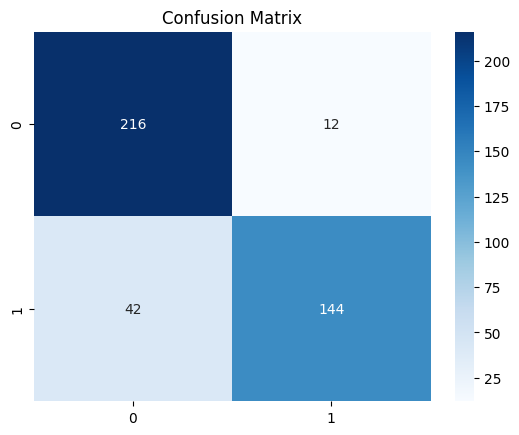

Macro F1: 0.8654970760233918


In [ ]:
y_pred = (final_model.predict(X_test_vec) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))


# Save Experiment Configuration

In [ ]:
import json
from pprint import pprint

experiment_config = {
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "bigru",
    "best_params": best,
    "embedding_dim": embedding_dim
}

print("\nExperiment Configuration:")
pprint(experiment_config)

print("\nJSON Format:")
print(json.dumps(experiment_config, indent=4))



Experiment Configuration:
{'best_params': {'dropout': 0.4527780273590106,
                 'h_units': 56,
                 'lr': 0.0023329771976242637},
 'embedding': 'fasttext',
 'embedding_dim': 300,
 'model': 'bigru',
 'tokenizer': 'spacy'}

JSON Format:
{
    "tokenizer": "spacy",
    "embedding": "fasttext",
    "model": "bigru",
    "best_params": {
        "h_units": 56,
        "dropout": 0.4527780273590106,
        "lr": 0.0023329771976242637
    },
    "embedding_dim": 300
}
